In [1]:
# %pip install catboost pyarrow -q

import warnings
warnings.filterwarnings("ignore")

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from catboost import CatBoostClassifier

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", "{:,.6f}".format)

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.config import (
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    FIGURES_DIR,
    REPORTS_DIR,
    SUBMISSIONS_DIR,
    TARGET_COL,
    ID_COL,
    RANDOM_STATE,
)

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
processed_files = sorted([p.name for p in PROCESSED_DATA_DIR.glob("*.parquet")])
print("Processed parquet files:")
for f in processed_files:
    print("-", f)

def find_first_existing(candidates):
    for name in candidates:
        path = PROCESSED_DATA_DIR / name
        if path.exists():
            return path
    raise FileNotFoundError(f"None of these files were found: {candidates}")

bureau_path = find_first_existing([
    "bureau_features.parquet"
])

previous_path = find_first_existing([
    "previous_application_features.parquet",
    "previous_features.parquet"
])

payment_path = find_first_existing([
    "payment_history_features.parquet"
])

print()
print("Using files:")
print("bureau   :", bureau_path.name)
print("previous :", previous_path.name)
print("payments :", payment_path.name)

Processed parquet files:
- bureau_features.parquet
- credit_card_features.parquet
- installments_features.parquet
- payment_history_features.parquet
- pos_cash_features.parquet
- previous_application_features.parquet

Using files:
bureau   : bureau_features.parquet
previous : previous_application_features.parquet
payments : payment_history_features.parquet


In [4]:
train = pd.read_csv(RAW_DATA_DIR / "application_train.csv")
test = pd.read_csv(RAW_DATA_DIR / "application_test.csv")

bureau_features = pd.read_parquet(bureau_path)
previous_features = pd.read_parquet(previous_path)
payment_features = pd.read_parquet(payment_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Bureau features shape:", bureau_features.shape)
print("Previous features shape:", previous_features.shape)
print("Payment features shape:", payment_features.shape)

Train shape: (307511, 122)
Test shape: (48744, 121)
Bureau features shape: (356255, 37)
Previous features shape: (356255, 39)
Payment features shape: (356255, 115)


In [5]:
train_model = (
    train
    .merge(bureau_features, on=ID_COL, how="left")
    .merge(previous_features, on=ID_COL, how="left")
    .merge(payment_features, on=ID_COL, how="left")
)

test_model = (
    test
    .merge(bureau_features, on=ID_COL, how="left")
    .merge(previous_features, on=ID_COL, how="left")
    .merge(payment_features, on=ID_COL, how="left")
)

print("Merged train shape:", train_model.shape)
print("Merged test shape:", test_model.shape)

display(train_model.head())

Merged train shape: (307511, 310)
Merged test shape: (48744, 309)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,...,INS_UNDERPAID_COUNT,INS_UNDERPAID_RATIO,INS_OVERPAID_COUNT,INS_OVERPAID_RATIO,INS_PAYMENT_RATIO_MEAN,INS_PAYMENT_RATIO_MIN,INS_PAYMENT_RATIO_MAX,INS_PAYMENT_DIFF_MEAN,INS_PAYMENT_DIFF_MIN,INS_PAYMENT_DIFF_MAX,INS_PAYMENT_DIFF_SUM,INS_AMT_PAYMENT_SUM,INS_AMT_PAYMENT_MEAN,INS_AMT_INSTALMENT_SUM,INS_AMT_INSTALMENT_MEAN,INS_DAYS_INSTALMENT_MIN,INS_DAYS_INSTALMENT_MAX,INS_DAYS_ENTRY_PAYMENT_MIN,INS_DAYS_ENTRY_PAYMENT_MAX,INS_TOTAL_PAYMENT_TO_INSTALMENT_RATIO,POS_SK_ID_PREV_NUNIQUE,POS_RECORD_COUNT,POS_MONTHS_BALANCE_MIN,POS_MONTHS_BALANCE_MAX,POS_MONTHS_BALANCE_SIZE,POS_CNT_INSTALMENT_MEAN,POS_CNT_INSTALMENT_MAX,POS_CNT_INSTALMENT_FUTURE_MEAN,POS_CNT_INSTALMENT_FUTURE_MAX,POS_SK_DPD_MEAN,POS_SK_DPD_MAX,POS_SK_DPD_DEF_MEAN,POS_SK_DPD_DEF_MAX,POS_DPD_COUNT,POS_DPD_RATIO,POS_DPD_DEF_COUNT,POS_DPD_DEF_RATIO,POS_STATUS_ACTIVE_COUNT,POS_STATUS_COMPLETED_COUNT,POS_STATUS_SIGNED_COUNT,POS_STATUS_DEMAND_COUNT,POS_STATUS_ACTIVE_RATIO,POS_STATUS_COMPLETED_RATIO,POS_STATUS_SIGNED_RATIO,POS_STATUS_DEMAND_RATIO,CC_SK_ID_PREV_NUNIQUE,CC_RECORD_COUNT,CC_MONTHS_BALANCE_MIN,CC_MONTHS_BALANCE_MAX,CC_MONTHS_BALANCE_SIZE,CC_AMT_BALANCE_MEAN,CC_AMT_BALANCE_MAX,CC_AMT_BALANCE_SUM,CC_AMT_CREDIT_LIMIT_ACTUAL_MEAN,CC_AMT_CREDIT_LIMIT_ACTUAL_MAX,CC_BALANCE_LIMIT_RATIO_MEAN,CC_BALANCE_LIMIT_RATIO_MAX,CC_AMT_DRAWINGS_CURRENT_MEAN,CC_AMT_DRAWINGS_CURRENT_MAX,CC_AMT_DRAWINGS_CURRENT_SUM,CC_DRAWINGS_LIMIT_RATIO_MEAN,CC_DRAWINGS_LIMIT_RATIO_MAX,CC_AMT_PAYMENT_CURRENT_MEAN,CC_AMT_PAYMENT_CURRENT_MAX,CC_AMT_PAYMENT_CURRENT_SUM,CC_AMT_PAYMENT_TOTAL_CURRENT_MEAN,CC_AMT_PAYMENT_TOTAL_CURRENT_MAX,CC_AMT_PAYMENT_TOTAL_CURRENT_SUM,CC_AMT_INST_MIN_REGULARITY_MEAN,CC_AMT_INST_MIN_REGULARITY_MAX,CC_PAYMENT_MIN_RATIO_MEAN,CC_PAYMENT_MIN_RATIO_MAX,CC_TOTAL_PAYMENT_BALANCE_RATIO_MEAN,CC_TOTAL_PAYMENT_BALANCE_RATIO_MAX,CC_CNT_DRAWINGS_CURRENT_MEAN,CC_CNT_DRAWINGS_CURRENT_MAX,CC_CNT_DRAWINGS_ATM_CURRENT_MEAN,CC_CNT_DRAWINGS_POS_CURRENT_MEAN,CC_CNT_INSTALMENT_MATURE_CUM_MEAN,CC_CNT_INSTALMENT_MATURE_CUM_MAX,CC_SK_DPD_MEAN,CC_SK_DPD_MAX,CC_SK_DPD_DEF_MEAN,CC_SK_DPD_DEF_MAX,CC_DPD_COUNT,CC_DPD_RATIO,CC_DPD_DEF_COUNT,CC_DPD_DEF_RATIO,CC_BALANCE_POSITIVE_COUNT,CC_BALANCE_POSITIVE_RATIO,CC_PAYMENT_LESS_THAN_MIN_COUNT,CC_PAYMENT_LESS_THAN_MIN

In [16]:
feature_cols = [c for c in train_model.columns if c not in [ID_COL, TARGET_COL]]
X = train_model[feature_cols].copy()
y = train_model[TARGET_COL].copy()
X_test = test_model[feature_cols].copy()

cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

for col in cat_cols:
    X[col] = X[col].astype("string").fillna("MISSING").astype(str)
    X_test[col] = X_test[col].astype("string").fillna("MISSING").astype(str)

num_cols = [c for c in X.columns if c not in cat_cols]

print("Number of features:", len(feature_cols))
print("Number of categorical columns:", len(cat_cols))
print("Number of numeric columns:", len(num_cols))

print("\nSample categorical columns:")
print(cat_cols[:20])

assert list(X.columns) == list(X_test.columns)

Number of features: 308
Number of categorical columns: 16
Number of numeric columns: 292

Sample categorical columns:
['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']


In [17]:
missing_summary = (
    X.isnull()
    .mean()
    .sort_values(ascending=False)
    .head(30)
    .rename("missing_ratio")
    .to_frame()
)

display(missing_summary)

,missing_ratio
CC_PAYMENT_MIN_RATIO_MAX,0.807262
CC_PAYMENT_MIN_RATIO_MEAN,0.807262
CC_TOTAL_PAYMENT_BALANCE_RATIO_MEAN,0.806183
CC_TOTAL_PAYMENT_BALANCE_RATIO_MAX,0.806183
CC_AMT_PAYMENT_CURRENT_MAX,0.801438
CC_AMT_PAYMENT_CURRENT_MEAN,0.801438
CC_AMT_PAYMENT_CURRENT_SUM,0.801438
CC_CNT_DRAWINGS_ATM_CURRENT_MEAN,0.801178
CC_CNT_DRAWINGS_POS_CURRENT_MEAN,0.801178
CC_BALANCE_LIMIT_RATIO_MAX,0.720218


In [18]:
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

params = {
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "iterations": 1500,
    "learning_rate": 0.05,
    "depth": 6,
    "l2_leaf_reg": 5,
    "random_seed": RANDOM_STATE,
    "verbose": 200,
    "auto_class_weights": "Balanced",
    "allow_writing_files": False,
}

oof_pred = np.zeros(len(X), dtype=float)
test_pred = np.zeros(len(X_test), dtype=float)

fold_scores = []
feature_importances = []

params

{'loss_function': 'Logloss',
 'eval_metric': 'AUC',
 'iterations': 1500,
 'learning_rate': 0.05,
 'depth': 6,
 'l2_leaf_reg': 5,
 'random_seed': 42,
 'verbose': 200,
 'auto_class_weights': 'Balanced',
 'allow_writing_files': False}

In [19]:
for fold, (train_idx, valid_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n========== Fold {fold} ==========")

    X_train = X.iloc[train_idx].copy()
    X_valid = X.iloc[valid_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_valid = y.iloc[valid_idx].copy()

    model = CatBoostClassifier(**params)

    model.fit(
        X_train,
        y_train,
        eval_set=(X_valid, y_valid),
        cat_features=cat_cols,
        use_best_model=True,
        early_stopping_rounds=100,
    )

    valid_pred = model.predict_proba(X_valid)[:, 1]
    oof_pred[valid_idx] = valid_pred

    fold_auc = roc_auc_score(y_valid, valid_pred)
    fold_scores.append(fold_auc)

    test_pred += model.predict_proba(X_test)[:, 1] / n_splits

    fold_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": model.get_feature_importance(),
        "fold": fold,
    })
    feature_importances.append(fold_importance)

    print(f"Fold {fold} AUC: {fold_auc:.6f}")


========== Fold 1 ==========
0:	test: 0.6910068	best: 0.6910068 (0)	total: 552ms	remaining: 13m 47s
200:	test: 0.7696463	best: 0.7696463 (200)	total: 1m 27s	remaining: 9m 23s
400:	test: 0.7777905	best: 0.7777905 (400)	total: 2m 51s	remaining: 7m 51s
600:	test: 0.7796454	best: 0.7796531 (594)	total: 4m 18s	remaining: 6m 27s
800:	test: 0.7804531	best: 0.7805408 (726)	total: 5m 46s	remaining: 5m 2s
1000:	test: 0.7810688	best: 0.7811610 (932)	total: 7m 14s	remaining: 3m 36s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.7815147862
bestIteration = 1087

Shrink model to first 1088 iterations.
Fold 1 AUC: 0.781515

========== Fold 2 ==========
0:	test: 0.7016048	best: 0.7016048 (0)	total: 458ms	remaining: 11m 26s
200:	test: 0.7778059	best: 0.7778059 (200)	total: 1m 31s	remaining: 9m 48s
400:	test: 0.7879029	best: 0.7879390 (399)	total: 3m 9s	remaining: 8m 40s
600:	test: 0.7898520	best: 0.7899205 (596)	total: 4m 38s	remaining: 6m 56s
Stopped by overfitting detector  (100

In [20]:
oof_auc = roc_auc_score(y, oof_pred)

baseline_oof_auc = 0.759895
bureau_previous_oof_auc = 0.772974

print("Fold AUC scores:", [round(s, 6) for s in fold_scores])
print(f"Mean fold AUC: {np.mean(fold_scores):.6f}")
print(f"OOF AUC: {oof_auc:.6f}")
print()
print(f"Baseline OOF AUC: {baseline_oof_auc:.6f}")
print(f"Bureau + Previous OOF AUC: {bureau_previous_oof_auc:.6f}")
print(f"Lift vs baseline: {oof_auc - baseline_oof_auc:.6f}")
print(f"Lift vs bureau + previous: {oof_auc - bureau_previous_oof_auc:.6f}")

Fold AUC scores: [0.781515, 0.790077, 0.783888, 0.78959, 0.781873]
Mean fold AUC: 0.785389
OOF AUC: 0.785274

Baseline OOF AUC: 0.759895
Bureau + Previous OOF AUC: 0.772974
Lift vs baseline: 0.025379
Lift vs bureau + previous: 0.012300


In [21]:
submission = pd.DataFrame({
    ID_COL: test_model[ID_COL],
    TARGET_COL: test_pred,
})

submission_path = SUBMISSIONS_DIR / "model_v4_with_payments.csv"
submission.to_csv(submission_path, index=False)

oof_df = pd.DataFrame({
    ID_COL: train_model[ID_COL],
    TARGET_COL: y,
    "OOF_PRED": oof_pred,
})

oof_path = REPORTS_DIR / "model_v4_with_payments_oof.csv"
oof_df.to_csv(oof_path, index=False)

print("Saved submission:", submission_path)
print("Saved OOF predictions:", oof_path)

display(submission.head())

Saved submission: C:\Coding\Home-Credit-Default-Risk\outputs\submissions\model_v4_with_payments.csv
Saved OOF predictions: C:\Coding\Home-Credit-Default-Risk\outputs\reports\model_v4_with_payments_oof.csv


,SK_ID_CURR,TARGET
0,100001,0.321199
1,100005,0.643408
2,100013,0.223825
3,100028,0.279653
4,100038,0.648655


In [22]:
feature_importance_df = pd.concat(feature_importances, axis=0, ignore_index=True)

feature_importance_mean = (
    feature_importance_df
    .groupby("feature", as_index=False)["importance"]
    .mean()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance_mean.head(30))

,feature,importance
0,EXT_SOURCE_3,8.769960
1,EXT_SOURCE_2,7.133875
2,EXT_SOURCE_1,3.924690
3,DAYS_BIRTH,3.192080
4,AMT_CREDIT,2.676793
5,AMT_ANNUITY,2.397871
6,AMT_GOODS_PRICE,2.199153
7,BUREAU_DEBT_CREDIT_RATIO_MEAN,1.837825
8,DAYS_EMPLOYED,1.721038
9,POS_CNT_INSTALMENT_FUTURE_MEAN,1.330537


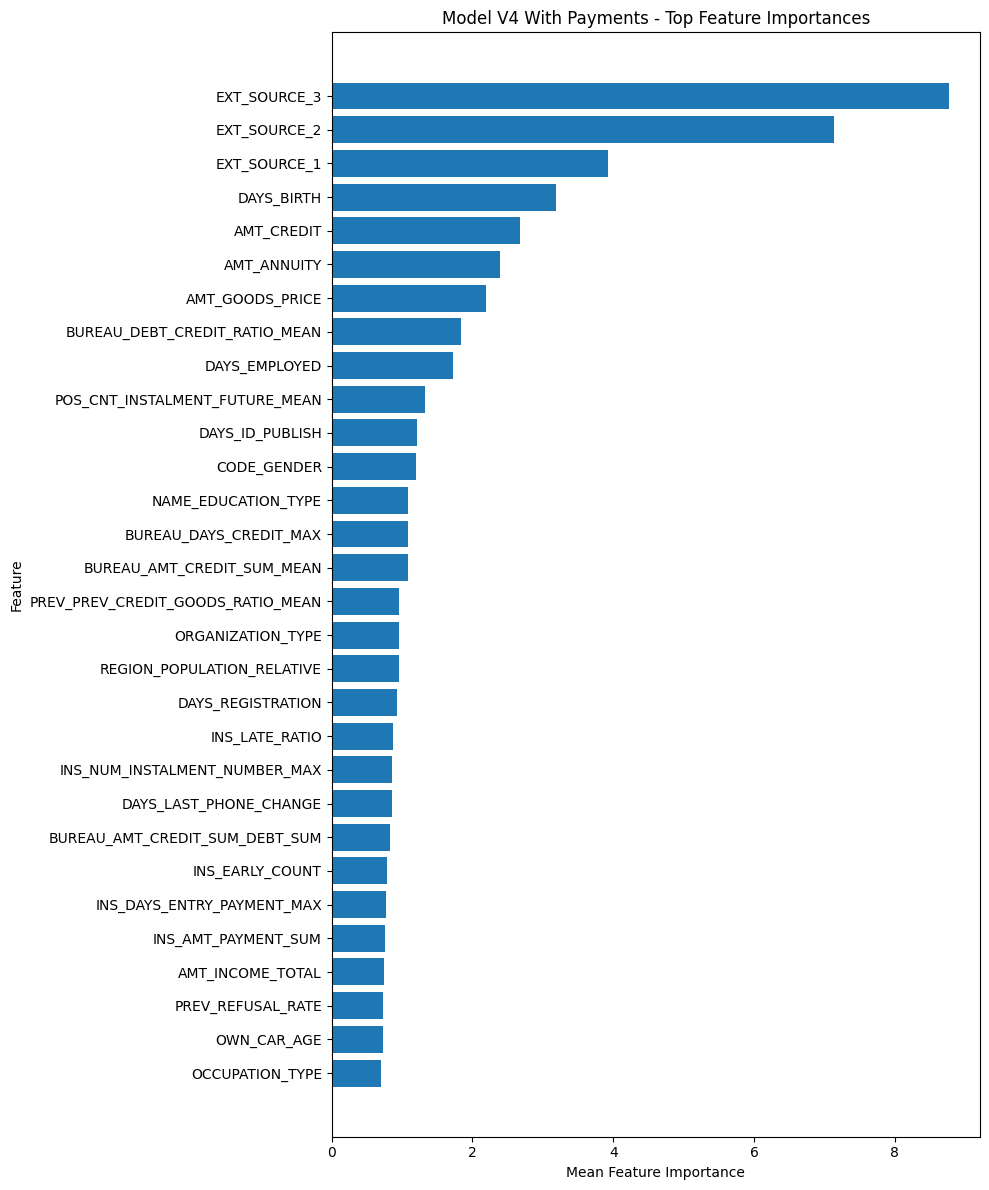

Saved figure: C:\Coding\Home-Credit-Default-Risk\outputs\figures\model_v4_with_payments_feature_importance.png


In [23]:
top_n = 30
plot_df = feature_importance_mean.head(top_n).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 12))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.xlabel("Mean Feature Importance")
plt.ylabel("Feature")
plt.title("Model V4 With Payments - Top Feature Importances")
plt.tight_layout()

figure_path = FIGURES_DIR / "model_v4_with_payments_feature_importance.png"
plt.savefig(figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved figure:", figure_path)

In [24]:
feature_importance_path = REPORTS_DIR / "model_v4_with_payments_feature_importance.csv"
feature_importance_mean.to_csv(feature_importance_path, index=False)

print("Saved feature importance table:", feature_importance_path)

Saved feature importance table: C:\Coding\Home-Credit-Default-Risk\outputs\reports\model_v4_with_payments_feature_importance.csv


In [25]:
report_path = REPORTS_DIR / "model_v4_with_payments.md"

report_lines = [
    "# Model V4 Results - Main Table + Bureau + Previous + Payment History",
    "",
    "## Dataset",
    f"- Train shape: {train.shape}",
    f"- Test shape: {test.shape}",
    f"- Bureau feature table shape: {bureau_features.shape}",
    f"- Previous application feature table shape: {previous_features.shape}",
    f"- Payment history feature table shape: {payment_features.shape}",
    f"- Final merged train feature matrix: {train_model.shape}",
    f"- Final merged test feature matrix: {test_model.shape}",
    f"- Number of categorical columns: {len(cat_cols)}",
    f"- Number of numeric columns: {len(num_cols)}",
    "",
    "## Cross-validation",
    f"- Number of folds: {n_splits}",
    f"- Fold AUC scores: {[round(s, 6) for s in fold_scores]}",
    f"- Mean fold AUC: {np.mean(fold_scores):.6f}",
    f"- OOF AUC: {oof_auc:.6f}",
    "",
    "## Comparison",
    f"- Baseline OOF AUC: {baseline_oof_auc:.6f}",
    f"- Bureau + Previous OOF AUC: {bureau_previous_oof_auc:.6f}",
    f"- OOF lift vs baseline: {oof_auc - baseline_oof_auc:.6f}",
    f"- OOF lift vs bureau + previous: {oof_auc - bureau_previous_oof_auc:.6f}",
    "",
    "## Outputs",
    f"- Submission file: {submission_path}",
    f"- OOF predictions file: {oof_path}",
    f"- Feature importance figure: {figure_path}",
    f"- Feature importance table: {feature_importance_path}",
    "",
    "## Top 20 Features",
]

for row in feature_importance_mean.head(20).itertuples(index=False):
    report_lines.append(f"- {row.feature}: {row.importance:.6f}")

report_path.write_text("\n".join(report_lines), encoding="utf-8")

print("Saved report:", report_path)
print(report_path.read_text(encoding="utf-8")[:2000])

Saved report: C:\Coding\Home-Credit-Default-Risk\outputs\reports\model_v4_with_payments.md
# Model V4 Results - Main Table + Bureau + Previous + Payment History

## Dataset
- Train shape: (307511, 122)
- Test shape: (48744, 121)
- Bureau feature table shape: (356255, 37)
- Previous application feature table shape: (356255, 39)
- Payment history feature table shape: (356255, 115)
- Final merged train feature matrix: (307511, 310)
- Final merged test feature matrix: (48744, 309)
- Number of categorical columns: 16
- Number of numeric columns: 292

## Cross-validation
- Number of folds: 5
- Fold AUC scores: [0.781515, 0.790077, 0.783888, 0.78959, 0.781873]
- Mean fold AUC: 0.785389
- OOF AUC: 0.785274

## Comparison
- Baseline OOF AUC: 0.759895
- Bureau + Previous OOF AUC: 0.772974
- OOF lift vs baseline: 0.025379
- OOF lift vs bureau + previous: 0.012300

## Outputs
- Submission file: C:\Coding\Home-Credit-Default-Risk\outputs\submissions\model_v4_with_payments.csv
- OOF predictions file

In [26]:
from pathlib import Path
import joblib

MODELS_DIR = project_root / "outputs" / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

final_model_path = MODELS_DIR / "model_v4_with_payments_fold5.joblib"
joblib.dump(model, final_model_path)

print("Saved model:", final_model_path)

Saved model: c:\Coding\Home-Credit-Default-Risk\outputs\models\model_v4_with_payments_fold5.joblib
